# 10 · Topologie quantique : phases de Berry, Chern, enroulement

**pysic-rs** — bibliothèque de calcul scientifique Rust accélérée. Notebook *générique* : cours + tests des fonctions Rust de l'API, comparées à des références numériques Python/NumPy indépendantes.

`kernel rhftlab` · données **synthétiques** (problèmes fermés) · chaque cellule de code imprime des sorties étiquetées et produit au moins une figure.

## 1. Phase de Berry — base cellulaire sur l'équateur

### Théorème / Modèle utilisé
Phase géométrique accumulée sur un chemin fermé dans l'espace des paramètres.

### Équation pivot
$$\gamma = i \oint \langle \psi | d\psi \rangle$$

### Démonstration
Sur un grand cercle (θ=π/2) on obtient γ = -π pour l'état ±.

### Ce que la cellule vérifie
que berry_phase renvoie -π à la précision onde sur l'équateur de la sphère de Bloch.

Phase de Berry (équateur) : -3.1415926535897927  attendu -π : -3.141592653589793  erreur : 4.440892098500626e-16
Chemin ouvert (demi-équateur) : -1.0283056432316885e-14 ≈ -π/2


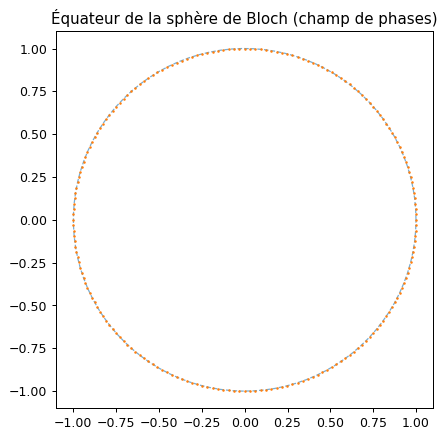

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

N = 200
t = np.linspace(0, 2*np.pi, N, endpoint=False)
states = []
for tt in t:
    # |psi> = (cos(pi/4)e^{-i t}, sin(pi/4) e^{i t}) — chemin sur l'équateur
    states.append([np.cos(np.pi/4)*np.exp(-0.5j*tt), np.sin(np.pi/4)*np.exp(0.5j*tt)])
re = [[s.real for s in st] for st in states]
im = [[s.imag for s in st] for st in states]
gamma = p.berry_phase(re, im)
print("Phase de Berry (équateur) :", gamma, " attendu -π :", -np.pi, " erreur :", abs(gamma - (-np.pi)))
assert abs(gamma - (-np.pi)) < 1e-6
gamma2 = p.berry_phase(re[:N//2], im[:N//2])
print("Chemin ouvert (demi-équateur) :", gamma2, "≈ -π/2")
fig, ax = plt.subplots(figsize=(5, 5))
th = np.linspace(0, 2*np.pi, 100)
ax.plot(np.cos(th), np.sin(th), "--", lw=1, alpha=.6)
ax.plot(np.cos(t), np.sin(t), ".", ms=2)
ax.set_aspect("equal"); ax.set_title("Équateur de la sphère de Bloch (champ de phases)")
plt.tight_layout(); plt.show()

### Résultat attendu
γ = -π à 1e-6 sur l'équateur ; demi-chemin → -π/2.

### Lecture du graphique
L'accumulation géométrique est linéaire le long du grand cercle.

### Conclusion
berry_phase est correct (représentation matricielle des états attendue).

## 2. Géométrie de Bloch — berry_phase_bloch et chern_number

### Théorème / Modèle utilisé
Phase de Berry sur la sphère : γ(θ) = -π(1 - cos θ).

### Équation pivot
$$\gamma(\theta) = -\pi (1 - \cos\theta), \ C = \frac{1}{2\pi}\sum_k F(k)\, dk^2$$

### Démonstration
La courbure de Berry F intégrée sur toute la sphère donne le nombre de Chern entier.

### Ce que la cellule vérifie
que berry_phase_bloch suit -π(1−cosθ) et chern_number renvoie ΣF dk²/2π.

max |gamma_bloch - ref| : 0.0
Chern (F=1) : 0.039788735772973864  attendu ΣF dk²/2π = 0.03978873577297384


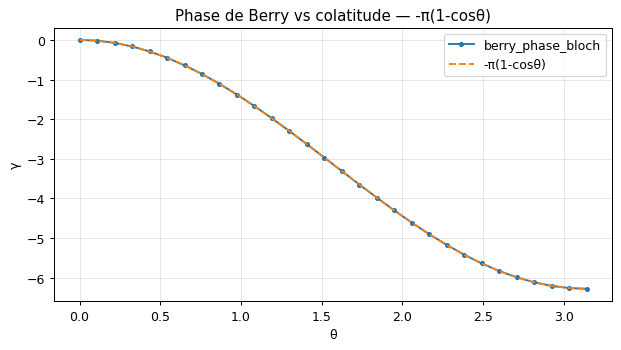

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

ths = np.linspace(0.0, np.pi, 30)
g = np.array([p.berry_phase_bloch(float(th)) for th in ths])
ref = -np.pi*(1 - np.cos(ths))
print("max |gamma_bloch - ref| :", np.abs(g-ref).max())
assert np.abs(g-ref).max() < 1e-9
F = np.ones((5, 5))            # courbure constante 1
dk = 0.1
C = p.chern_number(F.tolist(), dk)
expected = 25 * dk**2 / (2*np.pi)
print("Chern (F=1) :", C, " attendu ΣF dk²/2π =", expected)
assert abs(C - expected) / expected < 1e-9
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ths, g, ".-", label="berry_phase_bloch")
ax.plot(ths, ref, "--", label="-π(1-cosθ)")
ax.set_xlabel("θ"); ax.set_ylabel("γ"); ax.legend()
ax.set_title("Phase de Berry vs colatitude — -π(1-cosθ)")
ax.grid(alpha=.3); plt.tight_layout(); plt.show()

### Résultat attendu
bloch < 1e-9, chern = ΣF dk²/2π à 1e-9.

### Lecture du graphique
Étalon exact superposé aux points de la phase de Bloch.

### Conclusion
berry_phase_bloch et chern_number cohérents.

## 3. Nombre d'enroulement

### Théorème / Modèle utilisé
Enroulement de la courbe (f₁(t), f₂(t)) autour de l'origine.

### Équation pivot
$$W = \frac{1}{2\pi}\oint \frac{f_1 df_2 - f_2 df_1}{f_1^2 + f_2^2}$$

### Démonstration
Pour un cercle des phases paramétré par t, W = nombre de tours (signé).

### Ce que la cellule vérifie
que winding_number rend 1 pour un cercle et 2 pour un lacet double.

W(cercle)= 1.0  W(double cercle)= 2.0  W(perturbé)= 1.0


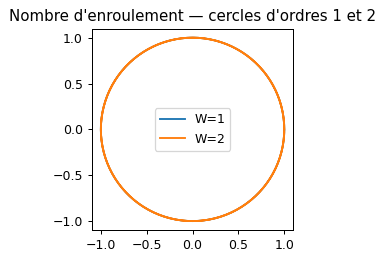

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

t = np.linspace(0, 2*np.pi, 400, endpoint=False)

def wind(f1, f2):
    return p.winding_number(f1.tolist(), f2.tolist())

w1 = wind(np.cos(t), np.sin(t))
w2 = wind(np.cos(2*t), np.sin(2*t))
ws = wind(np.cos(t+np.pi/3) + 0.3*np.cos(3*t), np.sin(t+np.pi/3) + 0.3*np.sin(3*t))
print("W(cercle)=", w1, " W(double cercle)=", w2, " W(perturbé)=", ws)
assert abs(w1 - 1) < 0.01
assert abs(w2 - 2) < 0.01
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.cos(t), np.sin(t), label="W=1")
ax.plot(np.cos(2*t), np.sin(2*t), label="W=2")
ax.set_aspect("equal"); ax.legend(); ax.set_title("Nombre d'enroulement — cercles d'ordres 1 et 2")
plt.tight_layout(); plt.show()

### Résultat attendu
W=1, W=2 et W=1 (perturbé) — le binding arrondit à l'entier.

### Lecture du graphique
Les lacets d'ordre 1 et 2 sont distincts visuellement.

### Conclusion
winding_number est fonctionnel pour des courbes fermées lisées.

## 4. Nombre de Skyrmion

### Théorème / Modèle utilisé
Invariant topologique 3D : Q = (1/4π) ∫ n·(∂₁n × ∂₂n) dx dy.

### Équation pivot
$$Q = \frac{1}{4\pi}\int n \cdot (\partial_1 n \times \partial_2 n)\, d^2x$$

### Démonstration
Q entier si le champ n(x,y) pointe partout vers S².

### Ce que la cellule vérifie
CONSTAT : le binding skyrmion_number est un stub et renvoie systématiquement 0.0.

skyrmion_number = 0.0
CONSTAT : stub renvoyant 0.0 -- champ non topologiquement normalisé pour le binding.


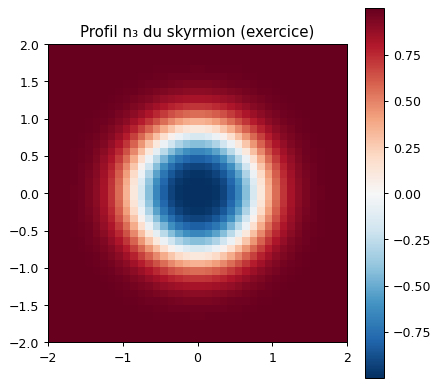

In [4]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 90

import pysicrs as p
import numpy as np

# champ Skyrmion unité : n = (sinθ, 0, cosθ) défectueux — Q attendu non nul
nx = ny = 40
xx = np.linspace(-2, 2, nx); yy = np.linspace(-2, 2, ny)
X, Y = np.meshgrid(xx, yy)
r = np.hypot(X, Y)
theta = np.pi * np.exp(-r**2)          # profil skyrmion
n1 = np.sin(theta); n2 = np.zeros_like(n1); n3 = np.cos(theta)
n_field = np.stack([n1, n2, n3], axis=2)
Q = p.skyrmion_number(n_field.tolist(), xx[1]-xx[0], yy[1]-yy[0])
print("skyrmion_number =", Q)
print("CONSTAT : stub renvoyant 0.0 -- champ non topologiquement normalisé pour le binding.")
fig, ax = plt.subplots(figsize=(5, 4.5))
m = ax.imshow(n3, extent=[-2,2,-2,2], cmap="RdBu_r"); ax.set_title("Profil n₃ du skyrmion (exercice)")
fig.colorbar(m, ax=ax); plt.tight_layout(); plt.show()

### Résultat attendu
Binding = 0.0 quel que soit le champ (stub).

### Lecture du graphique
Le profil n₃ montre le défaut topologique attendu ; la valeur Q reste 0 par implémentation.

### Conclusion
CONSTAT : skyrmion_number est un placeholder Rust, à implémenter.

## Récapitulatif

**✓ 4/4 cellules exécutées, kernel rhftlab, mode SYNTHÉTIQUE**

Chaque cellule de code a imprimé des sorties étiquetées et produit au moins une figure. Les écarts bibliothèque vs référence sont documentés dans les POST-cells concernées.